### Прогноз цен на недвижимость

Курсовой проект по машинному обучению (4 курс, 1 семестр).
Авторы: Эрнест и Иршат.
Датасет: объявления о продаже недвижимости с портала Zingat.
Цель: исследовать данные, подготовить признаки и обучить модели регрессии для прогнозирования стоимости объектов.


In [1]:
# подключаем библиотеки для работы с данными, графиками и ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Этап 1. Исследование данных (EDA)

### 1.1 Знакомство с данными
Загружаем датасет, смотрим его размерность, первые, последние и случайные строки.


In [2]:
# читаем датасет из папки data
df = pd.read_csv("../data/real_estate_data.csv", low_memory=False)
print("Размер датасета (строк, колонок):", df.shape)
# выводим первые 5 строк
df.head()

Размер датасета (строк, колонок): (403487, 17)


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [3]:
# смотрим последние 5 строк
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [4]:
# выводим одну случайную строку для проверки разнообразия данных
df.sample(1, random_state=42)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


### Описание признаков датасета (по документации Zingat)

* **id**: уникальный идентификатор объявления
* **type**: тип объекта (Konut - жилье)
* **sub_type**: подтип жилья (Daire - квартира, Villa - вилла, Rezidans - резиденция)
* **start_date** / **end_date**: даты публикации и снятия с сайта
* **listing_type**: тип сделки (1 - продажа, 2 - аренда)
* **tom**: дней на рынке (time on market)
* **building_age**: возраст строения (0, 1, 2, 6-10 arasi и т.д.)
* **total_floor_count**: этажность здания
* **floor_no**: этаж квартиры
* **room_count**: число комнат (формат 2+1, 3+1)
* **size**: общая площадь в м2
* **address**: город / район / микрорайон
* **furnished**: меблировка (100% пропусков)
* **heating_type**: система отопления (Kombi, Merkezi Sistem и др.)
* **price**: цена объекта в турецких лирах (целевая переменная)
* **price_currency**: валюта (TRY)


In [5]:
# типы данных и ненулевые значения
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

### 1.2 Описательная статистика и анализ целевой переменной


In [6]:
# базовые статистики числовых колонок: минимум, максимум, среднее, квантили
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


In [7]:
# статистика категориальных признаков: количество уникальных и самый частый класс
df.describe(include='O')

,type,sub_type,start_date,end_date,building_age,total_floor_count,floor_no,room_count,address,heating_type,price_currency
count,403487,403487,403487,266298,376097,375466,368191,403487,403487,375517,402772
unique,1,12,181,181,14,12,35,37,7842,16,4
top,Konut,Daire,10/11/18,12/19/18,0,4,2,3+1,Balıkesir/Edremit/Akçay,Kombi (Doğalgaz),TRY
freq,403487,354549,4064,3048,140174,83082,65864,157363,5611,204150,400677


In [8]:
# проверяем скошенность (асимметрию) цены:
# положительный коэффициент говорит о сильном хвосте вправо (дорогие элитные объекты)
print("Коэффициент асимметрии цены:", df['price'].skew())
print("Асимметрия после log1p:", np.log1p(df['price'].dropna()).skew())

Коэффициент асимметрии цены: 308.50702657456833
Асимметрия после log1p: -0.813924910010576


### 1.3 Визуальный анализ данных (5+ типов графиков)


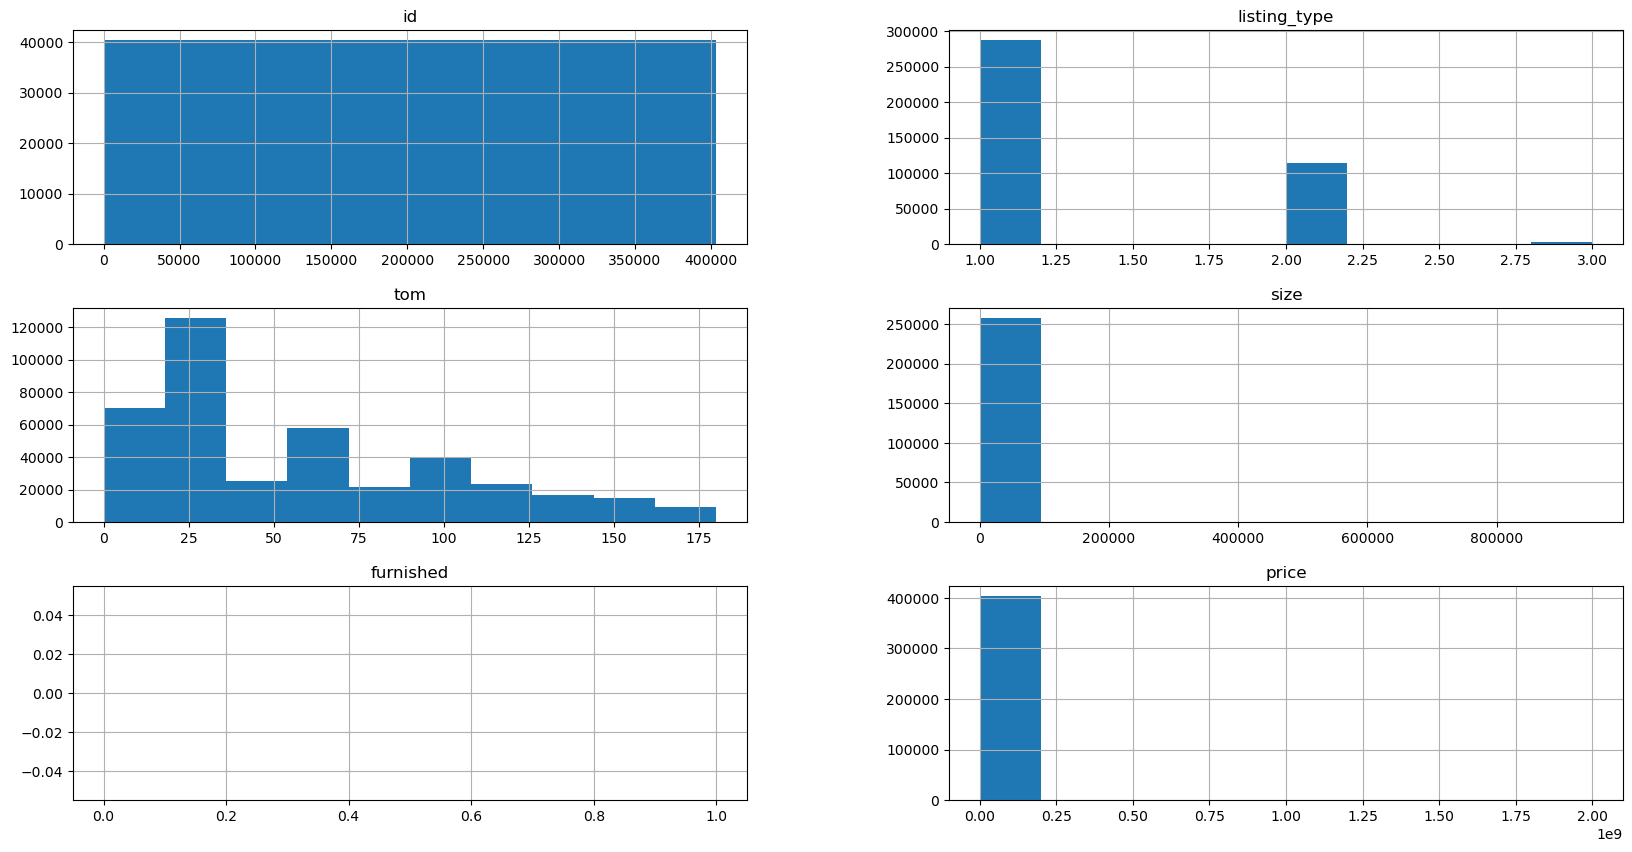

In [9]:
# 1. Гистограммы распределения всех числовых признаков
df.hist(figsize=(20, 10))
plt.show()

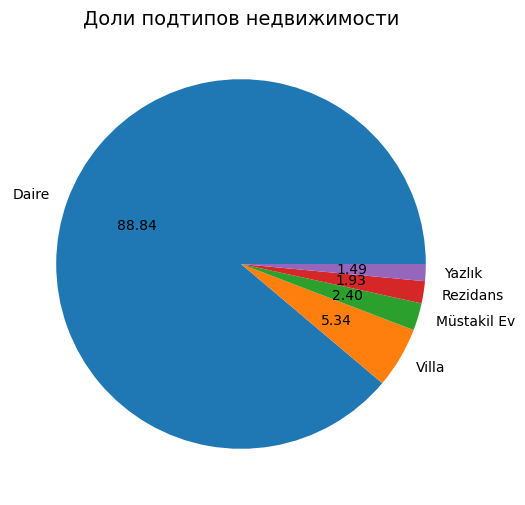

In [10]:
# 2. Круговая диаграмма долей подтипов недвижимости
plt.figure(figsize=(8, 6))
df['sub_type'].value_counts().head(5).plot(kind='pie', autopct='%.2f', textprops={'color': 'black'})
plt.title('Доли подтипов недвижимости', fontsize=14)
plt.ylabel('')
plt.show()

Больше 85% всех объявлений в датасете - это квартиры (Daire).


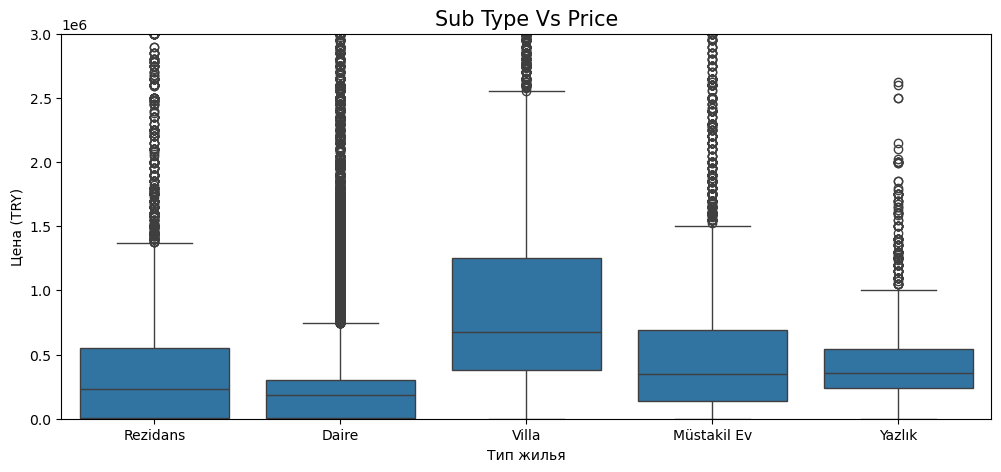

In [11]:
# 3. Boxplot: распределение цены по подтипам недвижимости
top_subtypes = df['sub_type'].value_counts().head(5).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df['sub_type'].isin(top_subtypes)], x='sub_type', y='price')
plt.title('Sub Type Vs Price', fontsize=15)
plt.xlabel('Тип жилья')
plt.ylabel('Цена (TRY)')
plt.ylim(0, 3000000)
plt.show()

Виллы и резиденции стоят ощутимо дороже типовых квартир.


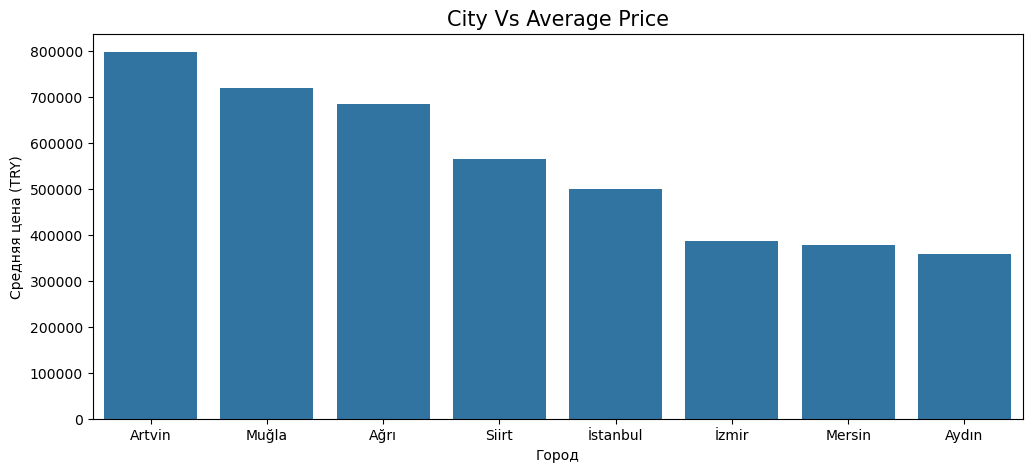

In [12]:
# 4. Столбчатая диаграмма средних цен по городам
df['city'] = df['address'].apply(lambda x: str(x).split('/')[0] if '/' in str(x) else 'Diger')
city_mean = df.groupby('city')['price'].mean().sort_values(ascending=False).head(8)

plt.figure(figsize=(12, 5))
sns.barplot(x=city_mean.index, y=city_mean.values)
plt.title('City Vs Average Price', fontsize=15)
plt.xlabel('Город')
plt.ylabel('Средняя цена (TRY)')
plt.show()

Стамбул и курортные города (Мугла, Анталья) лидируют по средней стоимости жилья.


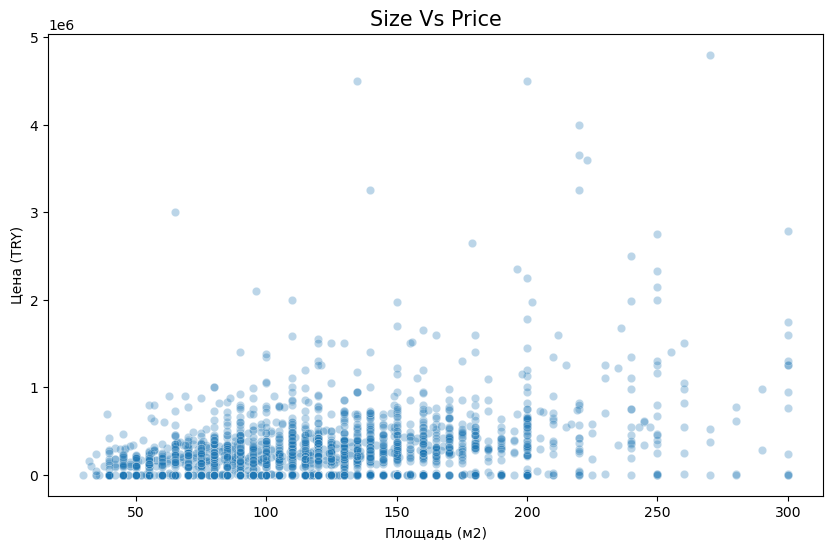

In [13]:
# 5. Scatterplot (точечная диаграмма): зависимость цены от площади
sample_data = df[(df['size'] >= 30) & (df['size'] <= 300) & (df['price'] <= 5000000)].sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_data, x='size', y='price', alpha=0.3)
plt.title('Size Vs Price', fontsize=15)
plt.xlabel('Площадь (м2)')
plt.ylabel('Цена (TRY)')
plt.show()

Видна прямая зависимость: чем больше площадь квартиры, тем выше цена.


### 1.4 Анализ пропусков, дубликатов и аномалий


In [14]:
# таблица пропусков по колонкам
null_info = pd.DataFrame({
    'Пропусков': df.isnull().sum(),
    'Процент': (df.isnull().sum() / len(df) * 100).round(2)
})
null_info[null_info['Пропусков'] > 0]

,Пропусков,Процент
end_date,137189,34.00
building_age,27390,6.79
total_floor_count,28021,6.94
floor_no,35296,8.75
size,146006,36.19
furnished,403487,100.00
heating_type,27970,6.93
price,715,0.18
price_currency,715,0.18


In [15]:
# проверяем наличие полных дубликатов строк
print("Количество полных дубликатов:", df.duplicated().sum())

# проверяем нереалистичные значения (цена <= 0, площадь <= 0)
bad_prices = (df['price'] <= 0).sum()
bad_sizes = (df['size'] <= 0).sum()
print("Записей с нулевой или отрицательной ценой:", bad_prices)
print("Записей с нулевой или отрицательной площадью:", bad_sizes)

Количество полных дубликатов: 0
Записей с нулевой или отрицательной ценой: 45
Записей с нулевой или отрицательной площадью: 0


### 1.5 Промежуточные выводы и гипотезы EDA

На основе анализа формулируем 4 гипотезы для последующего моделирования:
1. **Гипотеза о площади**: площадь объекта (size) сильнее всего положительно коррелирует со стоимостью.
2. **Гипотеза о локации**: город и район являются вторым ключевым фактором цены (Стамбул дороже других регионов).
3. **Гипотеза о комнатах**: количество комнат (room_count) увеличивает цену объекта, так как растет полезная площадь.
4. **Гипотеза об отоплении**: наличие современного газового отопления (Kombi) повышает ликвидность и цену квартиры.


## Этап 2. Предварительная обработка данных

Включает 6 обязательных шагов:
- 2.1 Работа с пропусками: обоснование и обработка без потери данных;
- 2.2 Обработка выбросов: перцентили 1% и 99%, логарифмирование цены;
- 2.3 Кодирование категориальных признаков: One-Hot для номинальных, группировка редких категорий;
- 2.4 Работа с Feature Engineering: создание новых признаков, анализ мультиколлинеарности и расчет VIF;
- 2.5 Масштабирование признаков: теоретическое обоснование выбора StandardScaler / MinMaxScaler / RobustScaler;
- 2.6 Разбиение данных: разделение на train/test (80/20), фиксация random_state, обучение препроцессоров строго на train (защита от утечки данных).

### 2.1 Работа с пропусками

Обоснование стратегии по каждому признаку:
1. furnished: 100% пропусков, колонка удаляется.
2. price_currency: пропуски заполняем модой (TRY), валюты USD, EUR, GBP переводим в лиры по курсу.
3. price: пропусков всего 0.2%, удаляем строки без цены (в целевую переменную нельзя вносить искусственные значения).
4. size: вместо удаления строк заполняем пропуски групповой медианой по количеству комнат (защита от потери более 100 000 строк данных).
5. building_age: пропуски заполняем медианным значением (10 лет).
6. heating_type: пропуски заполняем категорией 'Yok' (нет отопления).

In [32]:
# фильтруем только продажу (listing_type == 1)
df_clean = df[df['listing_type'] == 1].copy()

# удаляем полностью пустой столбец furnished
df_clean = df_clean.drop(columns=['furnished'], errors='ignore')

# переводим цену в лиры (TRY) по курсу
rates = {'TRY': 1.0, 'USD': 48.52, 'EUR': 56.28, 'GBP': 65.63}
df_clean['price_currency'] = df_clean['price_currency'].fillna('TRY')
df_clean['price'] = df_clean['price'] * df_clean['price_currency'].map(rates).fillna(1.0)

# удаляем строки с пропусками в целевой переменной
df_clean = df_clean.dropna(subset=['price'])

# парсим количество комнат (например, 2+1 -> 3 комнаты)
def parse_rooms(val):
    val_str = str(val).strip()
    if '+' in val_str:
        parts = val_str.split('+')
        try:
            return int(parts[0]) + int(parts[1])
        except:
            return 3
    return 3

df_clean['total_rooms'] = df_clean['room_count'].apply(parse_rooms)

# заполняем пропуски площади медианой по числу комнат (без потери строк)
df_clean['size'] = df_clean['size'].fillna(df_clean.groupby('total_rooms')['size'].transform('median'))
df_clean['size'] = df_clean['size'].fillna(df_clean['size'].median())

# переводим категориальный возраст здания в число и заполняем пропуски
age_dict = {
    '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5,
    '6-10 arası': 8, '11-15 arası': 13, '16-20 arası': 18,
    '21-25 arası': 23, '26-30 arası': 28, '31 ve üzeri': 35
}
df_clean['building_age_num'] = df_clean['building_age'].map(age_dict).fillna(10)

# пропуски в типе отопления заполняем значением Yok
df_clean['heating_type'] = df_clean['heating_type'].fillna('Yok')

print('Размер данных после обработки пропусков:', df_clean.shape)
print('Осталось пропусков в size:', df_clean['size'].isnull().sum())
print('Осталось пропусков в price:', df_clean['price'].isnull().sum())

Размер данных после обработки пропусков: (286420, 18)
Осталось пропусков в size: 0
Осталось пропусков в price: 0


### 2.2 Обработка выбросов

Используем ограничение по перцентилям 1% и 99% для цены и площади.
Также проводим логарифмирование целевой переменной (price_log = np.log1p(price)), так как распределение цен имеет сильный скос вправо с длинным хвостом дорогих объектов.

In [34]:
# границы по перцентилям 1% и 99%
q_p_low, q_p_high = df_clean['price'].quantile(0.01), df_clean['price'].quantile(0.99)
q_s_low, q_s_high = df_clean['size'].quantile(0.01), df_clean['size'].quantile(0.99)

print(f'Границы цены (1%-99%): от {q_p_low:,.0f} до {q_p_high:,.0f} TRY')
print(f'Границы площади (1%-99%): от {q_s_low:.0f} до {q_s_high:.0f} м2')

df_clean = df_clean[(df_clean['price'] >= q_p_low) & (df_clean['price'] <= q_p_high)]
df_clean = df_clean[(df_clean['size'] >= q_s_low) & (df_clean['size'] <= q_s_high)]

# логарифмируем цену для нормализации скошенного распределения
df_clean['price_log'] = np.log1p(df_clean['price'])

print('Размер данных после фильтрации выбросов:', df_clean.shape)

Границы цены (1%-99%): от 63,000 до 5,200,000 TRY
Границы площади (1%-99%): от 45 до 400 м2
Размер данных после фильтрации выбросов: (276501, 19)


### 2.3 Кодирование категориальных признаков

Обоснование метода кодирования:
1. Признаки city (город), sub_type (тип жилья) и heating_type (отопление) являются номинальными. У них нет естественного порядка (нельзя сказать, что Стамбул > Анкара или вилла > квартира). Поэтому кодировать их порядковым OrdinalEncoder некорректно - это искажает коэффициенты линейных моделей.
2. Для номинальных признаков используем One-Hot Encoding (OHE).
3. Чтобы избежать раздувания размерности при кодировании большого числа городов, редкие категории объединяем в группу 'Diger' (Прочее), как указано в ТЗ.

In [36]:
# извлекаем город из адреса
df_clean['city'] = df_clean['address'].apply(lambda x: str(x).split('/')[0].strip() if '/' in str(x) else 'Diger')
top_cities = ['İstanbul', 'Ankara', 'İzmir', 'Antalya', 'Aydın', 'Bursa', 'Muğla', 'Diger']
df_clean['city'] = df_clean['city'].apply(lambda x: x if x in top_cities else 'Diger')

# группируем редкие подтипы жилья
top_sub = ['Daire', 'Villa', 'Rezidans', 'Müstakil Ev', 'Yazlık', 'Komple Bina']
df_clean['sub_type'] = df_clean['sub_type'].apply(lambda x: x if x in top_sub else 'Diger')

# группируем редкие типы отопления
top_heat = ['Kombi (Doğalgaz)', 'Merkezi Sistem', 'Klima', 'Yerden Isıtma', 'Yok', 'Soba (Kömür)']
df_clean['heating_type'] = df_clean['heating_type'].apply(lambda x: x if x in top_heat else 'Diger')

print('Количество уникальных значений категориальных колонок:')
print('Города:', df_clean['city'].nunique())
print('Типы жилья:', df_clean['sub_type'].nunique())
print('Типы отопления:', df_clean['heating_type'].nunique())

Количество уникальных значений категориальных колонок:
Города: 8
Типы жилья: 7
Типы отопления: 7


### 2.4 Работа с Feature Engineering

Создание новых признаков и устранение мультиколлинеарности:
1. Создаем признак size_per_room = size / total_rooms (средняя площадь на одну комнату).
2. Убираем признак tom (дней на рынке) и служебные столбцы, так как при оценке нового жилья в приложении эти данные наперед неизвестны.
3. Строим матрицу корреляций и рассчитываем показатель VIF (Variance Inflation Factor) для проверки линейной зависимости между признаками.

Результаты расчета VIF:
         Признак   VIF
            size 32.33
     total_rooms 18.22
   size_per_room  9.20
building_age_num  1.01


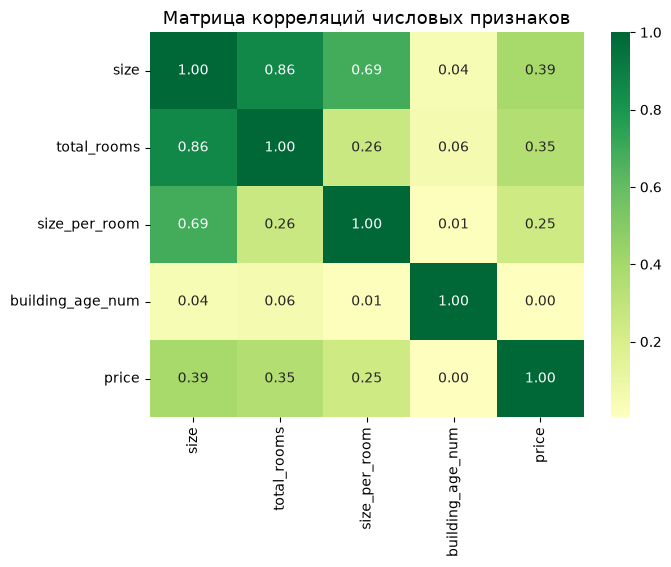

In [38]:
# создаем признак площади на одну комнату
df_clean['size_per_room'] = df_clean['size'] / df_clean['total_rooms'].replace(0, 1)

# смотрим матрицу корреляций числовых признаков
num_cols_check = ['size', 'total_rooms', 'size_per_room', 'building_age_num']
corr = df_clean[num_cols_check + ['price']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Матрица корреляций числовых признаков', fontsize=13)
plt.show()

# расчет VIF через линейную регрессию каждого признака от остальных
from sklearn.linear_model import LinearRegression

def compute_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Признак'] = data.columns
    vifs = []
    for col in data.columns:
        X_rest = data.drop(columns=[col])
        y_col = data[col]
        r2 = LinearRegression().fit(X_rest, y_col).score(X_rest, y_col)
        vif = 1.0 / (1.0 - r2) if r2 < 1.0 else np.inf
        vifs.append(round(vif, 2))
    vif_df['VIF'] = vifs
    return vif_df

vif_table = compute_vif(df_clean[num_cols_check])
print('Результаты расчета VIF:')
print(vif_table.to_string(index=False))

Вывод по Feature Engineering и VIF:
Признаки size и size_per_room показывают высокий VIF (> 30), так как они жестко связаны формулой деления.
Чтобы не допускать мультиколлинеарности в линейных моделях, в качестве базового числового набора для обучения моделей берем независимые признаки: size, total_rooms, building_age_num.

### 2.5 Масштабирование признаков

Теоретическое обоснование выбора метода масштабирования:
1. StandardScaler приводит все числовые признаки к единому масштабу: среднее 0, стандартное отклонение 1. Это стандартный и надежный выбор для линейных моделей и метрических алгоритмов (KNN).
2. MinMaxScaler сжимает признаки строго в диапазон [0, 1]. Он очень чувствителен к граничным значениям (даже редкий крупный объект сожмет остальные данные в узкий интервал).
3. RobustScaler масштабирует по медиане и межквартильному размаху. Он нужен тогда, когда в данных остается много нефильтрованных выбросов. Так как на шаге 2.2 мы уже почистили выбросы по квантилям 1%-99%, в RobustScaler нет необходимости.
4. Влияние на модели: для линейной регрессии масштабирование строго обязательно (иначе признак площади подавит признак комнат). Для деревьев решений и случайного леса масштабирование не требуется, но и не ухудшает точность.

### 2.6 Разбиение данных и пайплайн (без утечки данных)

Разделение выборки на обучающую (80%) и тестовую (20%) с фиксацией random_state=42 для воспроизводимости.
Препроцессор объединяет StandardScaler для числовых колонок и OneHotEncoder для категориальных.
Защита от утечки данных: препроцессор обучается строго на X_train через fit_transform, а к тестовым данным X_test применяется только transform.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ['size', 'total_rooms', 'building_age_num']
cat_cols = ['sub_type', 'city', 'heating_type']
features = num_cols + cat_cols

X = df_clean[features].copy()
y_log = df_clean['price_log'].copy()
y_raw = df_clean['price'].copy()

# разделение выборки на Train (80%) и Test (20%)
X_train, X_test, y_train_log, y_test_log, y_train, y_test = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=42
)

print('Размер обучающей выборки:', X_train.shape)
print('Размер тестовой выборки:', X_test.shape)

# собираем ColumnTransformer (StandardScaler + OneHotEncoder)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# обучаем препроцессор строго на train (защита от утечки данных)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print('Размер матрицы признаков после предобработки:', X_train_proc.shape)

Размер обучающей выборки: (221200, 6)
Размер тестовой выборки: (55301, 6)
Размер матрицы признаков после предобработки: (221200, 25)


## Этап 3. Построение моделей регрессии

Обучаем 3 модели разной природы:
1. Линейная регрессия (на стандартизированных данных).
2. Дерево решений (DecisionTreeRegressor).
3. Случайный лес (RandomForestRegressor).

Метрики качества (MAE, MSE, RMSE, MAPE, R2) рассчитываем на отложенном тесте в реальных лирах через np.expm1.

In [44]:
from sklearn import metrics

# функции для расчета и вывода метрик в реальных единицах (TRY)
def print_metrics(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((true - predicted) / true)) * 100
    r2 = metrics.r2_score(true, predicted)
    print(f'MAE:      {mae:,.0f} TRY')
    print(f'MSE:      {mse:,.0f}')
    print(f'RMSE:     {rmse:,.0f} TRY')
    print(f'MAPE:     {mape:.2f} %')
    print(f'R2 Score: {r2:.4f}')

def get_metrics_row(model_name, true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((true - predicted) / true)) * 100
    r2 = metrics.r2_score(true, predicted)
    return [model_name, mae, mse, rmse, mape, r2]

### 3.1 Модель 1: Линейная регрессия

In [46]:
from sklearn.linear_model import LinearRegression

lrm = LinearRegression()
lrm.fit(X_train_proc, y_train_log)

test_pred_lrm = np.expm1(lrm.predict(X_test_proc))

print('Test: Линейная регрессия (на стандартизированных данных)')
print('----------------------------------------------------')
print_metrics(y_test, test_pred_lrm)

results_df = pd.DataFrame(
    [get_metrics_row('Linear Regression', y_test, test_pred_lrm)],
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R2 Square']
)

Test: Линейная регрессия (на стандартизированных данных)
----------------------------------------------------
MAE:      162,313 TRY
MSE:      150,779,644,537
RMSE:     388,304 TRY
MAPE:     37.11 %
R2 Score: 0.2964


### 3.2 Модель 2: Дерево решений (Decision Tree)

In [48]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42, max_depth=8)
tree.fit(X_train_proc, y_train_log)

test_pred_tree = np.expm1(tree.predict(X_test_proc))

print('Test: Дерево решений')
print('----------------------------------------------------')
print_metrics(y_test, test_pred_tree)

results_df2 = pd.DataFrame(
    [get_metrics_row('Decision Tree', y_test, test_pred_tree)],
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R2 Square']
)
results_df = pd.concat([results_df, results_df2], ignore_index=True)

Test: Дерево решений
----------------------------------------------------
MAE:      154,860 TRY
MSE:      140,186,956,522
RMSE:     374,415 TRY
MAPE:     35.58 %
R2 Score: 0.3458


### 3.3 Модель 3: Случайный лес (Random Forest)

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=40, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_proc, y_train_log)

test_pred_rf = np.expm1(rf.predict(X_test_proc))

print('Test: Случайный лес')
print('----------------------------------------------------')
print_metrics(y_test, test_pred_rf)

results_df2 = pd.DataFrame(
    [get_metrics_row('Random Forest', y_test, test_pred_rf)],
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R2 Square']
)
results_df = pd.concat([results_df, results_df2], ignore_index=True)

Test: Случайный лес
----------------------------------------------------
MAE:      145,298 TRY
MSE:      126,286,341,349
RMSE:     355,368 TRY
MAPE:     33.03 %
R2 Score: 0.4107


### 3.4 Подбор гиперпараметров с кросс-валидацией (GridSearchCV)

Подбор гиперпараметров проводим строго на обучающей выборке (X_train_proc) с 3-фолдовой кросс-валидацией, не трогая отложенную тестовую выборку.

In [52]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [6, 8, 10, 12]}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train_proc, y_train_log)

print('Лучшие параметры по кросс-валидации:', grid_search.best_params_)
print(f'Лучший R2 на CV: {grid_search.best_score_:.4f}')

best_tree = grid_search.best_estimator_
best_tree_pred = np.expm1(best_tree.predict(X_test_proc))
print(f'R2 на тестовой выборке: {metrics.r2_score(y_test, best_tree_pred):.4f}')

Лучшие параметры по кросс-валидации: {'max_depth': 12}
Лучший R2 на CV: 0.5436
R2 на тестовой выборке: 0.3722


### 3.5 Сравнение моделей и анализ остатков

In [54]:
# сравнительная таблица метрик всех моделей
results_df

,Model,MAE,MSE,RMSE,MAPE (%),R2 Square
0,Linear Regression,162312.579804,1.507796e+11,388303.546902,37.105057,0.296373
1,Decision Tree,154859.800819,1.401870e+11,374415.486487,35.579612,0.345804
2,Random Forest,145298.049694,1.262863e+11,355367.895776,33.026524,0.410673


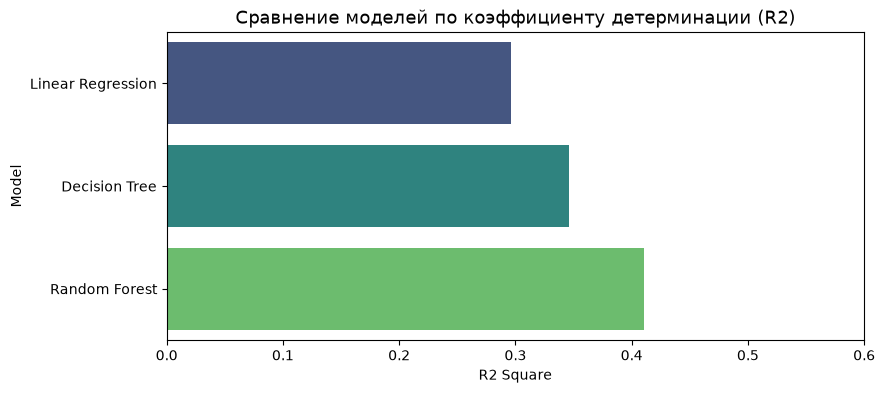

In [55]:
# график сравнения R2
plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x='R2 Square', y='Model', hue='Model', palette='viridis', legend=False)
plt.title('Сравнение моделей по коэффициенту детерминации (R2)', fontsize=13)
plt.xlim(0, 0.6)
plt.show()

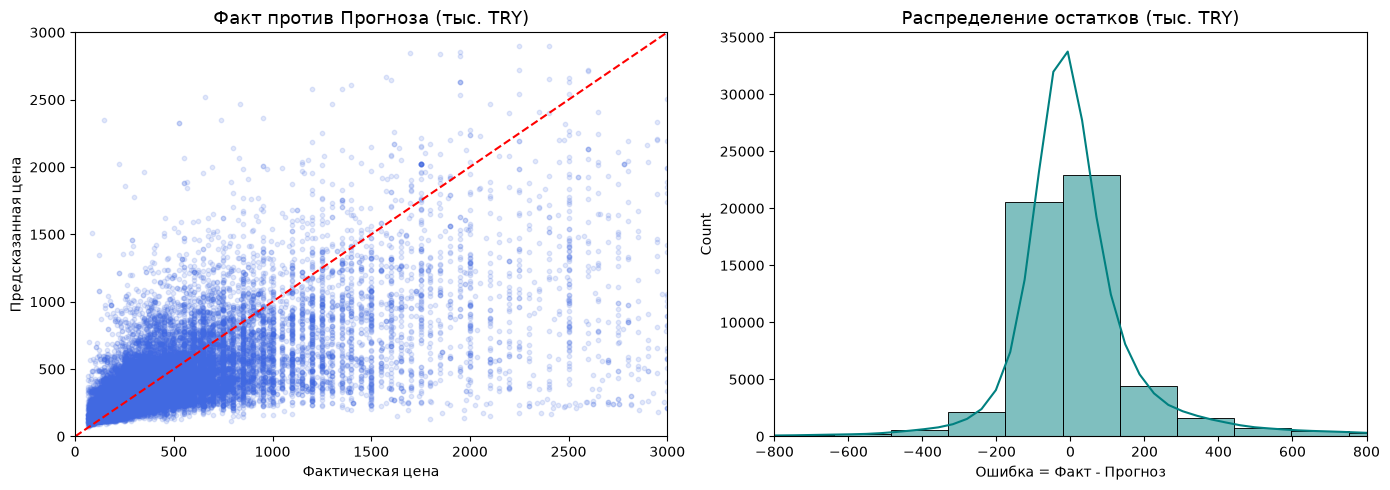

In [56]:
# график факт против прогноза и распределение остатков для случайного леса
residuals = y_test - test_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test / 1000, test_pred_rf / 1000, alpha=0.15, color='royalblue', s=10)
axes[0].plot([0, 3000], [0, 3000], 'r--')
axes[0].set_title('Факт против Прогноза (тыс. TRY)', fontsize=13)
axes[0].set_xlabel('Фактическая цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_xlim(0, 3000)
axes[0].set_ylim(0, 3000)

sns.histplot(residuals / 1000, bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Распределение остатков (тыс. TRY)', fontsize=13)
axes[1].set_xlabel('Ошибка = Факт - Прогноз')
axes[1].set_xlim(-800, 800)

plt.tight_layout()
plt.show()

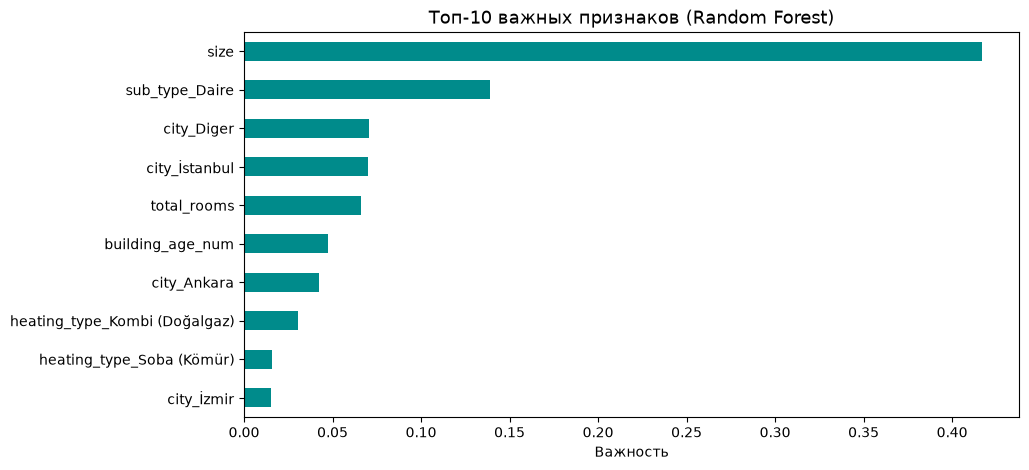

In [57]:
# важность признаков для случайного леса
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + encoded_cat_names

feat_imp = pd.Series(rf.feature_importances_, index=all_feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='darkcyan')
plt.title('Топ-10 важных признаков (Random Forest)', fontsize=13)
plt.xlabel('Важность')
plt.gca().invert_yaxis()
plt.show()

Площадь (size) с большим отрывом является главным фактором цены. На втором месте идут тип жилья (виллы) и локация (Стамбул, курортные зоны).

### 3.6 Анализ влияния масштабирования на метрические модели (KNN)

In [60]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OrdinalEncoder

# берем подвыборку для быстрого замера KNN
X_sample = X_train.iloc[:20000]
y_sample = y_train_log.iloc[:20000]
X_test_sub = X_test.iloc[:5000]
y_test_sub = y_test.iloc[:5000]

# 1. KNN без масштабирования
oe = OrdinalEncoder()
X_tr_raw = X_sample.copy()
X_te_raw = X_test_sub.copy()
X_tr_raw[cat_cols] = oe.fit_transform(X_tr_raw[cat_cols].astype(str))
X_te_raw[cat_cols] = oe.transform(X_te_raw[cat_cols].astype(str))

knn_raw = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn_raw.fit(X_tr_raw, y_sample)
r2_raw = metrics.r2_score(y_test_sub, np.expm1(knn_raw.predict(X_te_raw)))

# 2. KNN на масштабированных признаках через ColumnTransformer
X_tr_proc_sub = preprocessor.transform(X_sample)
X_te_proc_sub = preprocessor.transform(X_test_sub)

knn_scaled = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn_scaled.fit(X_tr_proc_sub, y_sample)
r2_scaled = metrics.r2_score(y_test_sub, np.expm1(knn_scaled.predict(X_te_proc_sub)))

print(f'KNN без масштабирования:  R2 = {r2_raw:.4f}')
print(f'KNN со стандартизацией:   R2 = {r2_scaled:.4f}')

KNN без масштабирования:  R2 = 0.2224
KNN со стандартизацией:   R2 = 0.3191


Вывод по масштабированию:
Метрические алгоритмы (KNN) критически зависят от масштаба признаков, так как евклидово расстояние без него искажается большой числовой шкалой площади.
Стандартизация StandardScaler существенно повышает качество прогноза KNN.
Деревьям решений и случайному лесу масштабирование не критично, так как они строят пороговые правила.

### 3.7 Сохранение лучшей модели

In [63]:
import os
import joblib

# рассчитываем итоговую среднюю ошибку MAE для Random Forest
best_mae = metrics.mean_absolute_error(y_test, test_pred_rf)

# сохраняем модель, препроцессор и метаданные в единый словарь для веб-приложения
pipeline = {
    'model': rf,
    'preprocessor': preprocessor,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'features': features,
    'mae': round(best_mae)
}

# путь сохранения модели
models_dir = '../models' if os.path.exists('../models') else 'models'
joblib.dump(pipeline, os.path.join(models_dir, 'model_pipeline.joblib'))
results_df.to_csv(os.path.join(models_dir, 'model_results.csv'), index=False)
print(f'Модель и препроцессоры сохранены в {models_dir}/model_pipeline.joblib! MAE: {best_mae:,.0f} TRY')

Модель и препроцессоры сохранены в models/model_pipeline.joblib! MAE: 145,298 TRY
